In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import (
    KMeans,
    BisectingKMeans,
    AgglomerativeClustering,
    DBSCAN,
    HDBSCAN,
    OPTICS,
    SpectralClustering,
    MeanShift,
    estimate_bandwidth,
    AffinityPropagation,
    Birch,
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.neighbors import kneighbors_graph

sns.set(style="whitegrid", context="talk")

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print("Warning: umap-learn is not installed. UMAP-based spaces will be skipped.")

try:
    import igraph as ig
    import leidenalg
    HAS_LEIDEN = True
except ImportError:
    HAS_LEIDEN = False
    print("Warning: igraph/leidenalg not installed. Leiden clustering will be skipped.")

In [3]:
DATA_DIR = Path("../../results/processed_hrv")
INPUT_FILE = DATA_DIR / "basal_v2_clean_with_categories.csv"

OUT_DIR = Path("../../results/clustering_exploration")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = OUT_DIR / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

LABEL_DIR = OUT_DIR / "labels"
LABEL_DIR.mkdir(parents=True, exist_ok=True)

META_DIR = OUT_DIR / "metadata"
META_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
df = pd.read_csv(INPUT_FILE)

print(df.shape)
df.head()

(530, 29)


,sex,age,weight_kg,height_cm_final,height_m_final,imc_final,bp_systolic,bp_diastolic,bp_pam,bp_pp,...,mean_hr_from_rr,height_inconsistent,imc_inconsistent,hr_rr_inconsistent,n_integrity_flags,n_range_flags,n_total_qc_flags,age_group,bmi_cat,bp_cat
0,1,75,70.0,160.0,1.60,27.343750,108,70,82.666667,38,...,80.213904,False,False,False,0,0,0,70-79,normal,normal
1,1,66,52.0,149.0,1.49,23.422368,122,72,88.666667,50,...,62.959077,False,False,False,0,0,0,60-69,normal,normal
2,2,77,81.0,170.0,1.70,28.027682,125,85,98.333333,40,...,68.415051,False,False,False,0,0,0,70-79,overweight,normal
3,1,77,85.0,160.0,1.60,33.203125,126,72,90.000000,54,...,73.260073,False,False,False,0,0,0,70-79,obesity,normal
4,1,73,69.0,151.0,1.51,30.261831,130,80,96.666667,50,...,70.921986,False,False,False,0,0,0,70-79,overweight,normal


In [5]:
hrv_cols = [
    "t2m_pre_mean_rr",
    "t2m_pre_mean_hr",
    "t2m_pre_sdnn",
    "t2m_pre_rmssd",
    "t2m_pre_hf",
    "t2m_pre_lf",
    "t2m_pre_vlf",
]

phys_cont_cols = [
    "age",
    "weight_kg",
    "height_m_final",
    "imc_final",
    "bp_systolic",
    "bp_diastolic",
    "bp_pam",
    "bp_pp",
]

phys_cat_cols = [
    "sex",
    "age_group",
    "bmi_cat",
    "bp_cat",
]

existing_hrv = [c for c in hrv_cols if c in df.columns]
existing_phys_cont = [c for c in phys_cont_cols if c in df.columns]
existing_phys_cat = [c for c in phys_cat_cols if c in df.columns]

existing_hrv, existing_phys_cont, existing_phys_cat

(['t2m_pre_mean_rr',
  't2m_pre_mean_hr',
  't2m_pre_sdnn',
  't2m_pre_rmssd',
  't2m_pre_hf',
  't2m_pre_lf',
  't2m_pre_vlf'],
 ['age',
  'weight_kg',
  'height_m_final',
  'imc_final',
  'bp_systolic',
  'bp_diastolic',
  'bp_pam',
  'bp_pp'],
 ['sex', 'age_group', 'bmi_cat', 'bp_cat'])

In [6]:
log_candidates = [
    "t2m_pre_sdnn",
    "t2m_pre_rmssd",
    "t2m_pre_hf",
    "t2m_pre_lf",
    "t2m_pre_vlf",
]

existing_log_candidates = [c for c in log_candidates if c in df.columns]

for col in existing_log_candidates:
    df[f"log_{col}"] = np.where(df[col] > 0, np.log1p(df[col]), np.nan)

log_hrv_cols = [f"log_{c}" for c in existing_log_candidates]
log_hrv_cols

['log_t2m_pre_sdnn',
 'log_t2m_pre_rmssd',
 'log_t2m_pre_hf',
 'log_t2m_pre_lf',
 'log_t2m_pre_vlf']

In [7]:
def impute_and_scale(df_in):
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_imp = imputer.fit_transform(df_in)
    X_scaled = scaler.fit_transform(X_imp)

    X_imp_df = pd.DataFrame(X_imp, columns=df_in.columns, index=df_in.index)
    X_scaled_df = pd.DataFrame(X_scaled, columns=df_in.columns, index=df_in.index)

    return X_imp_df, X_scaled_df, imputer, scaler

In [8]:
df_hrv_raw = df[existing_hrv].copy()
df_hrv_log = df[log_hrv_cols].copy()
df_phys = df[existing_phys_cont].copy()
df_integrated = df[log_hrv_cols + existing_phys_cont].copy()

X_hrv_raw_imp, X_hrv_raw_scaled, _, _ = impute_and_scale(df_hrv_raw)
X_hrv_log_imp, X_hrv_log_scaled, _, _ = impute_and_scale(df_hrv_log)
X_phys_imp, X_phys_scaled, _, _ = impute_and_scale(df_phys)
X_integrated_imp, X_integrated_scaled, _, _ = impute_and_scale(df_integrated)

print(X_hrv_raw_scaled.shape)
print(X_hrv_log_scaled.shape)
print(X_phys_scaled.shape)
print(X_integrated_scaled.shape)

(530, 7)
(530, 5)
(530, 8)
(530, 13)


In [9]:
def build_pca_space(X_df, n_components):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_df)
    cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    return pd.DataFrame(X_pca, columns=cols, index=X_df.index), pca

In [10]:
pca_spaces = {}

for name, X in {
    "hrv_log": X_hrv_log_scaled,
    "integrated": X_integrated_scaled,
}.items():
    for n_comp in [2, 3, 4, 5]:
        if X.shape[1] >= n_comp:
            X_pca_df, pca_model = build_pca_space(X, n_comp)
            pca_spaces[f"pca_{name}_{n_comp}d"] = X_pca_df

list(pca_spaces.keys())

['pca_hrv_log_2d',
 'pca_hrv_log_3d',
 'pca_hrv_log_4d',
 'pca_hrv_log_5d',
 'pca_integrated_2d',
 'pca_integrated_3d',
 'pca_integrated_4d',
 'pca_integrated_5d']

In [11]:
umap_spaces = {}

if HAS_UMAP:
    for name, X in {
        "hrv_log": X_hrv_log_scaled,
        "integrated": X_integrated_scaled,
    }.items():
        for n_neighbors in [10, 15, 30]:
            for min_dist in [0.0, 0.1, 0.3]:
                reducer = umap.UMAP(
                    n_neighbors=n_neighbors,
                    min_dist=min_dist,
                    n_components=2,
                    random_state=42
                )
                X_umap = reducer.fit_transform(X)
                key = f"umap_{name}_nn{n_neighbors}_md{str(min_dist).replace('.', '')}"
                umap_spaces[key] = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"], index=X.index)

list(umap_spaces.keys())[:10]

['umap_hrv_log_nn10_md00',
 'umap_hrv_log_nn10_md01',
 'umap_hrv_log_nn10_md03',
 'umap_hrv_log_nn15_md00',
 'umap_hrv_log_nn15_md01',
 'umap_hrv_log_nn15_md03',
 'umap_hrv_log_nn30_md00',
 'umap_hrv_log_nn30_md01',
 'umap_hrv_log_nn30_md03',
 'umap_integrated_nn10_md00']

In [12]:
tsne_spaces = {}

for name, X in {
    "hrv_log": X_hrv_log_scaled,
    "integrated": X_integrated_scaled,
}.items():
    for perplexity in [10, 20, 30, 40]:
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate="auto",
            init="pca",
            random_state=42
        )
        X_tsne = tsne.fit_transform(X)
        key = f"tsne_{name}_perp{perplexity}"
        tsne_spaces[key] = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"], index=X.index)

list(tsne_spaces.keys())

['tsne_hrv_log_perp10',
 'tsne_hrv_log_perp20',
 'tsne_hrv_log_perp30',
 'tsne_hrv_log_perp40',
 'tsne_integrated_perp10',
 'tsne_integrated_perp20',
 'tsne_integrated_perp30',
 'tsne_integrated_perp40']

In [13]:
input_spaces = {
    "hrv_raw_scaled": X_hrv_raw_scaled,
    "hrv_log_scaled": X_hrv_log_scaled,
    "phys_scaled": X_phys_scaled,
    "integrated_scaled": X_integrated_scaled,
}

input_spaces.update(pca_spaces)
input_spaces.update(umap_spaces)
input_spaces.update(tsne_spaces)

len(input_spaces), list(input_spaces.keys())[:20]

(38,
 ['hrv_raw_scaled',
  'hrv_log_scaled',
  'phys_scaled',
  'integrated_scaled',
  'pca_hrv_log_2d',
  'pca_hrv_log_3d',
  'pca_hrv_log_4d',
  'pca_hrv_log_5d',
  'pca_integrated_2d',
  'pca_integrated_3d',
  'pca_integrated_4d',
  'pca_integrated_5d',
  'umap_hrv_log_nn10_md00',
  'umap_hrv_log_nn10_md01',
  'umap_hrv_log_nn10_md03',
  'umap_hrv_log_nn15_md00',
  'umap_hrv_log_nn15_md01',
  'umap_hrv_log_nn15_md03',
  'umap_hrv_log_nn30_md00',
  'umap_hrv_log_nn30_md01'])

In [14]:
ALGORITHM_FAMILY_MAP = {
    "kmeans": "centroid-based",
    "bisecting_kmeans": "centroid-based",
    "gmm": "model-based",
    "agglomerative": "hierarchical-distance",
    "dbscan": "density-based",
    "hdbscan": "density-based",
    "optics": "density-based",
    "spectral": "graph-based",
    "meanshift": "density-based",
    "affinity_propagation": "message-passing",
    "birch": "hierarchical-centroid",
    "leiden_knn": "community-graph",
}

def get_algorithm_family(algorithm_name):
    return ALGORITHM_FAMILY_MAP.get(algorithm_name, "unknown")

ALGORITHM_FAMILY_MAP

{'kmeans': 'centroid-based',
 'bisecting_kmeans': 'centroid-based',
 'gmm': 'model-based',
 'agglomerative': 'hierarchical-distance',
 'dbscan': 'density-based',
 'hdbscan': 'density-based',
 'optics': 'density-based',
 'spectral': 'graph-based',
 'meanshift': 'density-based',
 'affinity_propagation': 'message-passing',
 'birch': 'hierarchical-centroid',
 'leiden_knn': 'community-graph'}

In [15]:
def get_cluster_counts(labels):
    labels = np.asarray(labels)
    valid = labels[labels != -1]
    counts = Counter(valid)
    return counts

def cluster_size_entropy(labels):
    counts = get_cluster_counts(labels)
    if len(counts) == 0:
        return np.nan
    probs = np.array(list(counts.values()), dtype=float)
    probs = probs / probs.sum()
    return -(probs * np.log2(probs)).sum()

def compute_basic_cluster_stats(labels):
    labels = np.asarray(labels)
    counts = get_cluster_counts(labels)

    n_total = len(labels)
    n_noise = int(np.sum(labels == -1))
    n_clustered = n_total - n_noise
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    if len(counts) > 0:
        sizes = np.array(list(counts.values()))
        min_size = int(sizes.min())
        max_size = int(sizes.max())
        median_size = float(np.median(sizes))
        imbalance_ratio = float(max_size / min_size) if min_size > 0 else np.nan
        entropy = cluster_size_entropy(labels)
    else:
        min_size = np.nan
        max_size = np.nan
        median_size = np.nan
        imbalance_ratio = np.nan
        entropy = np.nan

    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_fraction": n_noise / n_total,
        "n_clustered": n_total - n_noise,
        "min_cluster_size": min_size,
        "max_cluster_size": max_size,
        "median_cluster_size": median_size,
        "cluster_size_entropy": entropy,
        "imbalance_ratio": imbalance_ratio,
    }

def compute_internal_metrics(X, labels):
    labels = np.asarray(labels)
    unique_valid = set(labels) - {-1}

    if len(unique_valid) < 2:
        return {
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        }

    mask = labels != -1
    X_eval = X[mask]
    labels_eval = labels[mask]

    if len(np.unique(labels_eval)) < 2:
        return {
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        }

    return {
        "silhouette": silhouette_score(X_eval, labels_eval),
        "calinski_harabasz": calinski_harabasz_score(X_eval, labels_eval),
        "davies_bouldin": davies_bouldin_score(X_eval, labels_eval),
    }

In [16]:
def run_kmeans(X, n_clusters, random_state=42):
    model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=20)
    labels = model.fit_predict(X)
    return labels


def run_bisecting_kmeans(X, n_clusters, random_state=42):
    model = BisectingKMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        bisecting_strategy="largest_cluster"
    )
    labels = model.fit_predict(X)
    return labels


def run_gmm(X, n_components, covariance_type, random_state=42):
    model = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        random_state=random_state
    )
    labels = model.fit_predict(X)
    return labels


def run_agglomerative(X, n_clusters, linkage, metric="euclidean"):
    if linkage == "ward":
        model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
    else:
        model = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=linkage,
            metric=metric
        )
    labels = model.fit_predict(X)
    return labels


def run_dbscan(X, eps, min_samples, metric="euclidean"):
    model = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
    labels = model.fit_predict(X)
    return labels


def run_hdbscan(X, min_cluster_size=5, min_samples=None, cluster_selection_method="eom"):
    model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_method=cluster_selection_method
    )
    labels = model.fit_predict(X)
    return labels


def run_optics(X, min_samples, xi, min_cluster_size):
    model = OPTICS(
        min_samples=min_samples,
        xi=xi,
        min_cluster_size=min_cluster_size
    )
    labels = model.fit_predict(X)
    return labels


def run_spectral(X, n_clusters, affinity="nearest_neighbors", random_state=42):
    model = SpectralClustering(
        n_clusters=n_clusters,
        affinity=affinity,
        random_state=random_state,
        assign_labels="kmeans"
    )
    labels = model.fit_predict(X)
    return labels


def run_meanshift(X, bandwidth=None):
    model = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    labels = model.fit_predict(X)
    return labels


def run_affinity(X, damping=0.9, preference=None, random_state=42):
    model = AffinityPropagation(
        damping=damping,
        preference=preference,
        random_state=random_state
    )
    labels = model.fit_predict(X)
    return labels


def run_birch(X, n_clusters=None, threshold=0.5, branching_factor=50):
    model = Birch(
        n_clusters=n_clusters,
        threshold=threshold,
        branching_factor=branching_factor
    )
    labels = model.fit_predict(X)
    return labels

In [17]:
def run_leiden_knn(X, n_neighbors=15, resolution=1.0):
    if not HAS_LEIDEN:
        raise ImportError("Leiden dependencies not available.")

    knn = kneighbors_graph(X, n_neighbors=n_neighbors, mode="connectivity", include_self=False)
    sources, targets = knn.nonzero()
    edges = list(zip(sources.tolist(), targets.tolist()))

    g = ig.Graph(n=X.shape[0], edges=edges, directed=False)
    partition = leidenalg.find_partition(
        g,
        leidenalg.RBConfigurationVertexPartition,
        resolution_parameter=resolution
    )
    labels = np.array(partition.membership)
    return labels

In [18]:
def estimate_meanshift_bandwidth_safe(X, quantile=0.2, n_samples=None):
    try:
        bw = estimate_bandwidth(X, quantile=quantile, n_samples=n_samples)
        if bw is None or bw <= 0:
            return None
        return bw
    except Exception:
        return None

In [19]:
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
gmm_covariances = ["full", "diag", "tied", "spherical"]
agg_linkages = ["ward", "complete", "average", "single"]

dbscan_eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
dbscan_min_samples_values = [5, 10, 15, 20]

hdbscan_min_cluster_sizes = [5, 10, 15, 20, 30]
hdbscan_min_samples_values = [None, 5, 10, 15, 20]
hdbscan_selection_methods = ["eom", "leaf"]

optics_min_samples_values = [5, 10, 15, 20]
optics_xi_values = [0.01, 0.03, 0.05, 0.1]
optics_min_cluster_sizes = [0.03, 0.05, 0.1]

spectral_affinities = ["nearest_neighbors", "rbf"]

meanshift_quantiles = [0.1, 0.2, 0.3]
meanshift_n_samples = [None, 200]

affinity_dampings = [0.7, 0.8, 0.9, 0.95]
affinity_preferences = [None, -50, -10, -1]

birch_thresholds = [0.3, 0.5, 0.7, 1.0]
birch_branching_factors = [25, 50, 100]
birch_n_clusters = [None, 2, 3, 4, 5, 6, 7, 8, 9, 10]

leiden_n_neighbors = [5, 10, 15, 20, 25, 30]
leiden_resolutions = [0.5, 1.0, 1.5, 2.0]

In [20]:
experiments = []

for space_name, X_df in input_spaces.items():
    # KMeans
    for k in k_values:
        algorithm = "kmeans"
        experiments.append({
            "algorithm": algorithm,
            "family": get_algorithm_family(algorithm),
            "space_name": space_name,
            "params": {"n_clusters": k},
        })

    # Bisecting KMeans
    for k in k_values:
        algorithm = "bisecting_kmeans"
        experiments.append({
            "algorithm": algorithm,
            "family": get_algorithm_family(algorithm),
            "space_name": space_name,
            "params": {"n_clusters": k},
        })

    # GMM
    for k in k_values:
        for cov in gmm_covariances:
            algorithm = "gmm"
            experiments.append({
                "algorithm": algorithm,
                "family": get_algorithm_family(algorithm),
                "space_name": space_name,
                "params": {"n_components": k, "covariance_type": cov},
            })

    # Agglomerative
    for k in k_values:
        for linkage in agg_linkages:
            algorithm = "agglomerative"
            experiments.append({
                "algorithm": algorithm,
                "family": get_algorithm_family(algorithm),
                "space_name": space_name,
                "params": {"n_clusters": k, "linkage": linkage},
            })

    # DBSCAN
    for eps in dbscan_eps_values:
        for min_samples in dbscan_min_samples_values:
            algorithm = "dbscan"
            experiments.append({
                "algorithm": algorithm,
                "family": get_algorithm_family(algorithm),
                "space_name": space_name,
                "params": {"eps": eps, "min_samples": min_samples},
            })

    # HDBSCAN
    for min_cluster_size in hdbscan_min_cluster_sizes:
        for min_samples in hdbscan_min_samples_values:
            for method in hdbscan_selection_methods:
                algorithm = "hdbscan"
                experiments.append({
                    "algorithm": algorithm,
                    "family": get_algorithm_family(algorithm),
                    "space_name": space_name,
                    "params": {
                        "min_cluster_size": min_cluster_size,
                        "min_samples": min_samples,
                        "cluster_selection_method": method,
                    },
                })

    # OPTICS
    for min_samples in optics_min_samples_values:
        for xi in optics_xi_values:
            for min_cluster_size in optics_min_cluster_sizes:
                algorithm = "optics"
                experiments.append({
                    "algorithm": algorithm,
                    "family": get_algorithm_family(algorithm),
                    "space_name": space_name,
                    "params": {
                        "min_samples": min_samples,
                        "xi": xi,
                        "min_cluster_size": min_cluster_size,
                    },
                })

    # Spectral
    for k in k_values:
        for affinity in spectral_affinities:
            algorithm = "spectral"
            experiments.append({
                "algorithm": algorithm,
                "family": get_algorithm_family(algorithm),
                "space_name": space_name,
                "params": {"n_clusters": k, "affinity": affinity},
            })

    # MeanShift
    for quantile in meanshift_quantiles:
        for n_samples in meanshift_n_samples:
            algorithm = "meanshift"
            experiments.append({
                "algorithm": algorithm,
                "family": get_algorithm_family(algorithm),
                "space_name": space_name,
                "params": {"quantile": quantile, "n_samples": n_samples},
            })

    # AffinityPropagation
    for damping in affinity_dampings:
        for preference in affinity_preferences:
            algorithm = "affinity_propagation"
            experiments.append({
                "algorithm": algorithm,
                "family": get_algorithm_family(algorithm),
                "space_name": space_name,
                "params": {"damping": damping, "preference": preference},
            })

    # Birch
    for threshold in birch_thresholds:
        for branching_factor in birch_branching_factors:
            for n_clusters in birch_n_clusters:
                algorithm = "birch"
                experiments.append({
                    "algorithm": algorithm,
                    "family": get_algorithm_family(algorithm),
                    "space_name": space_name,
                    "params": {
                        "threshold": threshold,
                        "branching_factor": branching_factor,
                        "n_clusters": n_clusters,
                    },
                })

    # Leiden
    if HAS_LEIDEN:
        for nn in leiden_n_neighbors:
            for res in leiden_resolutions:
                algorithm = "leiden_knn"
                experiments.append({
                    "algorithm": algorithm,
                    "family": get_algorithm_family(algorithm),
                    "space_name": space_name,
                    "params": {"n_neighbors": nn, "resolution": res},
                })

len(experiments)

24168

In [21]:
exp_count_by_algorithm = pd.Series([e["algorithm"] for e in experiments]).value_counts()
exp_count_by_family = pd.Series([e["family"] for e in experiments]).value_counts()

print("Total experiments:", len(experiments))
print("\nBy algorithm:")
print(exp_count_by_algorithm)
print("\nBy family:")
print(exp_count_by_family)

Total experiments: 24168

By algorithm:
birch                   4560
agglomerative           4408
gmm                     4408
spectral                2204
hdbscan                 1900
optics                  1824
kmeans                  1102
bisecting_kmeans        1102
dbscan                   912
leiden_knn               912
affinity_propagation     608
meanshift                228
Name: count, dtype: int64

By family:
density-based            4864
hierarchical-centroid    4560
hierarchical-distance    4408
model-based              4408
centroid-based           2204
graph-based              2204
community-graph           912
message-passing           608
Name: count, dtype: int64


In [22]:
def run_single_experiment(exp, input_spaces, random_state=42):
    algorithm = exp["algorithm"]
    family = exp.get("family", get_algorithm_family(algorithm))
    space_name = exp["space_name"]
    params = exp["params"]

    X_df = input_spaces[space_name]
    X = X_df.values

    try:
        if algorithm == "kmeans":
            labels = run_kmeans(X, n_clusters=params["n_clusters"], random_state=random_state)

        elif algorithm == "bisecting_kmeans":
            labels = run_bisecting_kmeans(X, n_clusters=params["n_clusters"], random_state=random_state)

        elif algorithm == "gmm":
            labels = run_gmm(
                X,
                n_components=params["n_components"],
                covariance_type=params["covariance_type"],
                random_state=random_state
            )

        elif algorithm == "agglomerative":
            labels = run_agglomerative(
                X,
                n_clusters=params["n_clusters"],
                linkage=params["linkage"]
            )

        elif algorithm == "dbscan":
            labels = run_dbscan(
                X,
                eps=params["eps"],
                min_samples=params["min_samples"]
            )

        elif algorithm == "hdbscan":
            labels = run_hdbscan(
                X,
                min_cluster_size=params["min_cluster_size"],
                min_samples=params["min_samples"],
                cluster_selection_method=params["cluster_selection_method"]
            )

        elif algorithm == "optics":
            labels = run_optics(
                X,
                min_samples=params["min_samples"],
                xi=params["xi"],
                min_cluster_size=params["min_cluster_size"]
            )

        elif algorithm == "spectral":
            labels = run_spectral(
                X,
                n_clusters=params["n_clusters"],
                affinity=params["affinity"],
                random_state=random_state
            )

        elif algorithm == "meanshift":
            bw = estimate_meanshift_bandwidth_safe(
                X,
                quantile=params["quantile"],
                n_samples=params["n_samples"]
            )
            labels = run_meanshift(X, bandwidth=bw)

        elif algorithm == "affinity_propagation":
            labels = run_affinity(
                X,
                damping=params["damping"],
                preference=params["preference"],
                random_state=random_state
            )

        elif algorithm == "birch":
            labels = run_birch(
                X,
                n_clusters=params["n_clusters"],
                threshold=params["threshold"],
                branching_factor=params["branching_factor"]
            )

        elif algorithm == "leiden_knn":
            labels = run_leiden_knn(
                X,
                n_neighbors=params["n_neighbors"],
                resolution=params["resolution"]
            )

        else:
            raise ValueError(f"Unknown algorithm: {algorithm}")

        basic_stats = compute_basic_cluster_stats(labels)
        internal_metrics = compute_internal_metrics(X, labels)

        result = {
            "status": "ok",
            "algorithm": algorithm,
            "family": family,
            "space_name": space_name,
            "params_json": json.dumps(params, sort_keys=True),
            **basic_stats,
            **internal_metrics,
        }

        return result, labels

    except Exception as e:
        result = {
            "status": "error",
            "algorithm": algorithm,
            "family": family,
            "space_name": space_name,
            "params_json": json.dumps(params, sort_keys=True),
            "error_message": str(e),
        }
        return result, None

In [23]:
results = []
label_index = []

for i, exp in enumerate(experiments):
    result, labels = run_single_experiment(exp, input_spaces=input_spaces, random_state=42)

    result["experiment_id"] = i
    results.append(result)

    if labels is not None:
        label_file = LABEL_DIR / f"labels_exp_{i:05d}.csv"
        pd.DataFrame({
            "row_id": df.index,
            "cluster_label": labels
        }).to_csv(label_file, index=False)

        label_index.append({
            "experiment_id": i,
            "label_file": str(label_file),
            "algorithm": exp["algorithm"],
            "family": exp["family"],
            "space_name": exp["space_name"],
            "params_json": json.dumps(exp["params"], sort_keys=True),
        })

results_df = pd.DataFrame(results)
label_index_df = pd.DataFrame(label_index)

results_df.head()

,status,algorithm,family,space_name,params_json,n_clusters,n_noise,noise_fraction,n_clustered,min_cluster_size,max_cluster_size,median_cluster_size,cluster_size_entropy,imbalance_ratio,silhouette,calinski_harabasz,davies_bouldin,experiment_id
0,ok,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 2}",2,0,0.0,530,37.0,493.0,265.0,0.365219,13.324324,0.598903,170.712611,1.192077,0
1,ok,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 3}",3,0,0.0,530,35.0,310.0,185.0,1.241492,8.857143,0.273415,174.708670,1.232019,1
2,ok,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 4}",4,0,0.0,530,29.0,175.0,163.0,1.802967,6.034483,0.242396,156.408032,1.252247,2
3,ok,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 5}",5,0,0.0,530,15.0,172.0,157.0,1.889536,11.466667,0.257802,153.493475,1.274984,3
4,ok,kmeans,centroid-based,hrv_raw_scaled,"{""n_clusters"": 6}",6,0,0.0,530,10.0,172.0,84.5,1.991712,17.200000,0.277803,152.634911,1.167301,4


In [24]:
results_df.to_csv(TABLE_DIR / "clustering_exploration_results.csv", index=False)
label_index_df.to_csv(TABLE_DIR / "clustering_label_index.csv", index=False)

results_df.shape, label_index_df.shape

((24168, 18), (24168, 6))

In [25]:
valid_results_df = results_df[results_df["status"] == "ok"].copy()
valid_results_df.shape

(24168, 18)

In [26]:
rank_silhouette = valid_results_df.sort_values(
    ["silhouette", "n_clusters", "noise_fraction"],
    ascending=[False, True, True]
)

rank_silhouette.head(10)

,status,algorithm,family,space_name,params_json,n_clusters,n_noise,noise_fraction,n_clustered,min_cluster_size,max_cluster_size,median_cluster_size,cluster_size_entropy,imbalance_ratio,silhouette,calinski_harabasz,davies_bouldin,experiment_id
11103,ok,dbscan,density-based,umap_hrv_log_nn15_md03,"{""eps"": 0.3, ""min_samples"": 10}",2,507,0.956604,23,10.0,13.0,11.5,0.987693,1.300000,0.969930,10198.314153,0.042532,11103
20027,ok,dbscan,density-based,tsne_hrv_log_perp20,"{""eps"": 2.0, ""min_samples"": 10}",2,506,0.954717,24,10.0,14.0,12.0,0.979869,1.400000,0.967166,9037.775213,0.044566,20027
11108,ok,dbscan,density-based,umap_hrv_log_nn15_md03,"{""eps"": 0.5, ""min_samples"": 15}",2,499,0.941509,31,15.0,16.0,15.5,0.999249,1.066667,0.966024,10702.984750,0.047276,11108
16192,ok,dbscan,density-based,umap_integrated_nn15_md01,"{""eps"": 0.3, ""min_samples"": 15}",2,499,0.941509,31,15.0,16.0,15.5,0.999249,1.066667,0.958389,7260.195540,0.058951,16192
15673,ok,optics,density-based,umap_integrated_nn15_md00,"{""min_cluster_size"": 0.03, ""min_samples"": 20, ...",2,490,0.924528,40,19.0,21.0,20.0,0.998196,1.105263,0.950048,6029.500673,0.068863,15673
21301,ok,dbscan,density-based,tsne_hrv_log_perp40,"{""eps"": 2.0, ""min_samples"": 20}",2,485,0.915094,45,20.0,25.0,22.5,0.991076,1.250000,0.948573,6951.052338,0.073137,21301
11741,ok,dbscan,density-based,umap_hrv_log_nn30_md00,"{""eps"": 0.3, ""min_samples"": 20}",4,444,0.837736,86,20.0,26.0,20.0,1.989903,1.300000,0.945106,34561.320739,0.083787,11741
12376,ok,dbscan,density-based,umap_hrv_log_nn30_md01,"{""eps"": 0.3, ""min_samples"": 15}",4,467,0.881132,63,15.0,18.0,15.0,1.995237,1.200000,0.942911,18257.507135,0.081039,12376
11209,ok,optics,density-based,umap_hrv_log_nn15_md03,"{""min_cluster_size"": 0.03, ""min_samples"": 15, ...",3,464,0.875472,66,16.0,28.0,22.0,1.548736,1.750000,0.932120,6455.384877,0.096612,11209
17465,ok,dbscan,density-based,umap_integrated_nn30_md00,"{""eps"": 0.3, ""min_samples"": 20}",3,464,0.875472,66,21.0,23.0,22.0,1.583969,1.095238,0.930355,5626.859946,0.098004,17465


In [28]:
rank_ch = valid_results_df.sort_values(
    ["calinski_harabasz", "n_clusters", "noise_fraction"],
    ascending=[False, True, True]
)

rank_ch.head(10)

,status,algorithm,family,space_name,params_json,n_clusters,n_noise,noise_fraction,n_clustered,min_cluster_size,max_cluster_size,median_cluster_size,cluster_size_entropy,imbalance_ratio,silhouette,calinski_harabasz,davies_bouldin,experiment_id
11741,ok,dbscan,density-based,umap_hrv_log_nn30_md00,"{""eps"": 0.3, ""min_samples"": 20}",4,444,0.837736,86,20.0,26.0,20.0,1.989903,1.300000,0.945106,34561.320739,0.083787,11741
9832,ok,dbscan,density-based,umap_hrv_log_nn15_md00,"{""eps"": 0.3, ""min_samples"": 15}",10,336,0.633962,194,15.0,24.0,19.5,3.294400,1.600000,0.857069,22338.485780,0.205920,9832
12376,ok,dbscan,density-based,umap_hrv_log_nn30_md01,"{""eps"": 0.3, ""min_samples"": 15}",4,467,0.881132,63,15.0,18.0,15.0,1.995237,1.200000,0.942911,18257.507135,0.081039,12376
19582,ok,birch,hierarchical-centroid,tsne_hrv_log_perp10,"{""branching_factor"": 50, ""n_clusters"": null, ""...",491,0,0.000000,530,1.0,2.0,1.0,8.902679,2.000000,0.108163,17027.402386,0.062424,19582
19592,ok,birch,hierarchical-centroid,tsne_hrv_log_perp10,"{""branching_factor"": 100, ""n_clusters"": null, ...",492,0,0.000000,530,1.0,2.0,1.0,8.906452,2.000000,0.105414,16994.439540,0.061738,19592
19572,ok,birch,hierarchical-centroid,tsne_hrv_log_perp10,"{""branching_factor"": 25, ""n_clusters"": null, ""...",494,0,0.000000,530,1.0,2.0,1.0,8.913999,2.000000,0.098120,16311.594631,0.061692,19572
9922,ok,optics,density-based,umap_hrv_log_nn15_md00,"{""min_cluster_size"": 0.03, ""min_samples"": 10, ...",14,227,0.428302,303,17.0,33.0,21.0,3.780803,1.941176,0.729827,15384.867559,0.370116,9922
9925,ok,optics,density-based,umap_hrv_log_nn15_md00,"{""min_cluster_size"": 0.03, ""min_samples"": 10, ...",13,237,0.447170,293,17.0,37.0,21.0,3.665432,2.176471,0.763121,14598.964374,0.331117,9925
9855,ok,hdbscan,density-based,umap_hrv_log_nn15_md00,"{""cluster_selection_method"": ""leaf"", ""min_clus...",47,89,0.167925,441,5.0,23.0,9.0,5.429036,4.600000,0.653428,14453.591159,0.409747,9855
9857,ok,hdbscan,density-based,umap_hrv_log_nn15_md00,"{""cluster_selection_method"": ""leaf"", ""min_clus...",47,89,0.167925,441,5.0,23.0,9.0,5.429036,4.600000,0.653428,14453.591159,0.409747,9857


In [27]:
rank_db = valid_results_df.sort_values(
    ["davies_bouldin", "n_clusters", "noise_fraction"],
    ascending=[True, True, True]
)

rank_db.head(10)

,status,algorithm,family,space_name,params_json,n_clusters,n_noise,noise_fraction,n_clustered,min_cluster_size,max_cluster_size,median_cluster_size,cluster_size_entropy,imbalance_ratio,silhouette,calinski_harabasz,davies_bouldin,experiment_id
22126,ok,birch,hierarchical-centroid,tsne_integrated_perp10,"{""branching_factor"": 50, ""n_clusters"": null, ""...",515,0,0.000000,530,1.0,2.0,1.0,8.993245,2.000000,0.046739,10860.664851,0.020689,22126
22116,ok,birch,hierarchical-centroid,tsne_integrated_perp10,"{""branching_factor"": 25, ""n_clusters"": null, ""...",516,0,0.000000,530,1.0,2.0,1.0,8.997018,2.000000,0.043390,10757.693026,0.021314,22116
22136,ok,birch,hierarchical-centroid,tsne_integrated_perp10,"{""branching_factor"": 100, ""n_clusters"": null, ...",514,0,0.000000,530,1.0,2.0,1.0,8.989471,2.000000,0.049603,10686.965006,0.021603,22136
11103,ok,dbscan,density-based,umap_hrv_log_nn15_md03,"{""eps"": 0.3, ""min_samples"": 10}",2,507,0.956604,23,10.0,13.0,11.5,0.987693,1.300000,0.969930,10198.314153,0.042532,11103
20027,ok,dbscan,density-based,tsne_hrv_log_perp20,"{""eps"": 2.0, ""min_samples"": 10}",2,506,0.954717,24,10.0,14.0,12.0,0.979869,1.400000,0.967166,9037.775213,0.044566,20027
11108,ok,dbscan,density-based,umap_hrv_log_nn15_md03,"{""eps"": 0.5, ""min_samples"": 15}",2,499,0.941509,31,15.0,16.0,15.5,0.999249,1.066667,0.966024,10702.984750,0.047276,11108
22752,ok,birch,hierarchical-centroid,tsne_integrated_perp20,"{""branching_factor"": 25, ""n_clusters"": null, ""...",494,0,0.000000,530,1.0,2.0,1.0,8.913999,2.000000,0.107311,8412.630281,0.054576,22752
22772,ok,birch,hierarchical-centroid,tsne_integrated_perp20,"{""branching_factor"": 100, ""n_clusters"": null, ...",494,0,0.000000,530,1.0,2.0,1.0,8.913999,2.000000,0.104763,7431.531818,0.057632,22772
22762,ok,birch,hierarchical-centroid,tsne_integrated_perp20,"{""branching_factor"": 50, ""n_clusters"": null, ""...",492,0,0.000000,530,1.0,2.0,1.0,8.906452,2.000000,0.112661,8323.629861,0.057740,22762
16192,ok,dbscan,density-based,umap_integrated_nn15_md01,"{""eps"": 0.3, ""min_samples"": 15}",2,499,0.941509,31,15.0,16.0,15.5,0.999249,1.066667,0.958389,7260.195540,0.058951,16192


In [29]:
rank_balanced = valid_results_df.copy()

rank_balanced["silhouette_rank"] = rank_balanced["silhouette"].rank(ascending=False, method="average")
rank_balanced["ch_rank"] = rank_balanced["calinski_harabasz"].rank(ascending=False, method="average")
rank_balanced["db_rank"] = rank_balanced["davies_bouldin"].rank(ascending=True, method="average")
rank_balanced["noise_rank"] = rank_balanced["noise_fraction"].rank(ascending=True, method="average")

rank_balanced["consensus_rank_score"] = (
    rank_balanced["silhouette_rank"] +
    rank_balanced["ch_rank"] +
    rank_balanced["db_rank"] +
    rank_balanced["noise_rank"]
)

rank_balanced = rank_balanced.sort_values("consensus_rank_score", ascending=True)
rank_balanced.head(10)

,status,algorithm,family,space_name,params_json,n_clusters,n_noise,noise_fraction,n_clustered,min_cluster_size,...,imbalance_ratio,silhouette,calinski_harabasz,davies_bouldin,experiment_id,silhouette_rank,ch_rank,db_rank,noise_rank,consensus_rank_score
11506,ok,gmm,model-based,umap_hrv_log_nn30_md00,"{""covariance_type"": ""full"", ""n_components"": 2}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11506,145.0,2463.0,147.0,10165.0,12920.0
11991,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11991,145.0,2463.0,147.0,10165.0,12920.0
11507,ok,gmm,model-based,umap_hrv_log_nn30_md00,"{""covariance_type"": ""diag"", ""n_components"": 2}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11507,145.0,2463.0,147.0,10165.0,12920.0
11961,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11961,145.0,2463.0,147.0,10165.0,12920.0
11922,ok,meanshift,density-based,umap_hrv_log_nn30_md00,"{""n_samples"": null, ""quantile"": 0.3}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11922,145.0,2463.0,147.0,10165.0,12920.0
11923,ok,meanshift,density-based,umap_hrv_log_nn30_md00,"{""n_samples"": 200, ""quantile"": 0.3}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11923,145.0,2463.0,147.0,10165.0,12920.0
12021,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,12021,145.0,2463.0,147.0,10165.0,12920.0
12041,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 50, ""n_clusters"": 2, ""thr...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,12041,145.0,2463.0,147.0,10165.0,12920.0
11981,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 50, ""n_clusters"": 2, ""thr...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11981,145.0,2463.0,147.0,10165.0,12920.0
11622,ok,agglomerative,hierarchical-distance,umap_hrv_log_nn30_md00,"{""linkage"": ""ward"", ""n_clusters"": 2}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11622,145.0,2463.0,147.0,10165.0,12920.0


In [30]:
valid_results_df["algorithm"].value_counts()

algorithm
birch                   4560
agglomerative           4408
gmm                     4408
spectral                2204
hdbscan                 1900
optics                  1824
kmeans                  1102
bisecting_kmeans        1102
dbscan                   912
leiden_knn               912
affinity_propagation     608
meanshift                228
Name: count, dtype: int64

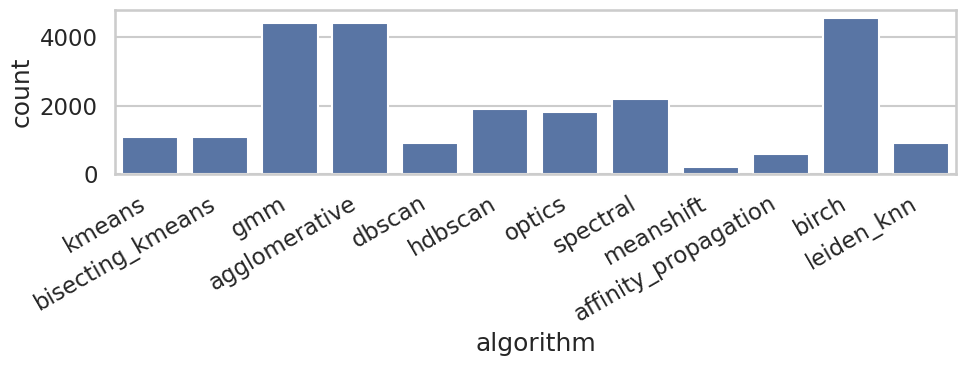

In [31]:
plt.figure(figsize=(10, 4))
sns.countplot(data=valid_results_df, x="algorithm")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "valid_experiments_by_algorithm.png", dpi=300)
plt.show()

In [32]:
valid_results_df["family"].value_counts()

family
density-based            4864
hierarchical-centroid    4560
hierarchical-distance    4408
model-based              4408
centroid-based           2204
graph-based              2204
community-graph           912
message-passing           608
Name: count, dtype: int64

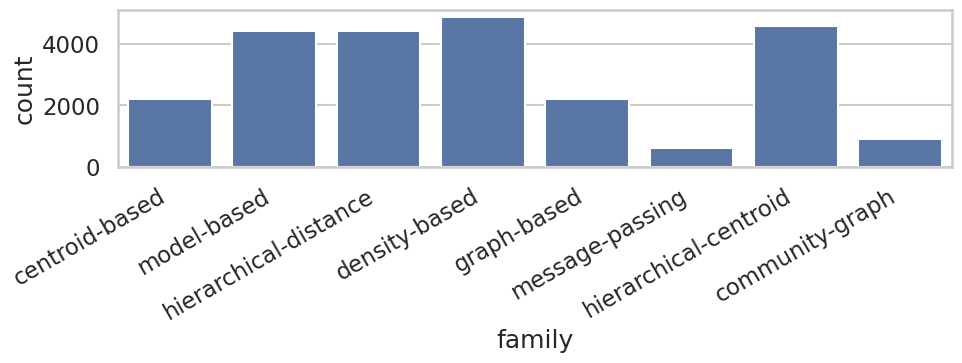

In [33]:
plt.figure(figsize=(10, 4))
sns.countplot(data=valid_results_df, x="family")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "valid_experiments_by_family.png", dpi=300)
plt.show()

In [34]:
valid_results_df["space_name"].value_counts().head(20)

space_name
hrv_raw_scaled            636
hrv_log_scaled            636
phys_scaled               636
integrated_scaled         636
pca_hrv_log_2d            636
pca_hrv_log_3d            636
pca_hrv_log_4d            636
pca_hrv_log_5d            636
pca_integrated_2d         636
pca_integrated_3d         636
pca_integrated_4d         636
pca_integrated_5d         636
umap_hrv_log_nn10_md00    636
umap_hrv_log_nn10_md01    636
umap_hrv_log_nn10_md03    636
umap_hrv_log_nn15_md00    636
umap_hrv_log_nn15_md01    636
umap_hrv_log_nn15_md03    636
umap_hrv_log_nn30_md00    636
umap_hrv_log_nn30_md01    636
Name: count, dtype: int64

In [35]:
metric_summary_algo = valid_results_df.groupby("algorithm").agg(
    n_runs=("experiment_id", "count"),
    silhouette_mean=("silhouette", "mean"),
    silhouette_max=("silhouette", "max"),
    ch_mean=("calinski_harabasz", "mean"),
    ch_max=("calinski_harabasz", "max"),
    db_mean=("davies_bouldin", "mean"),
    db_min=("davies_bouldin", "min"),
    mean_clusters=("n_clusters", "mean"),
    mean_noise_fraction=("noise_fraction", "mean"),
).reset_index()

metric_summary_algo

,algorithm,n_runs,silhouette_mean,silhouette_max,ch_mean,ch_max,db_mean,db_min,mean_clusters,mean_noise_fraction
0,affinity_propagation,608,0.373688,0.620903,1588.349733,12935.947575,0.782914,0.071493,57.712171,0.000000
1,agglomerative,4408,0.270067,0.784369,958.401174,9988.030860,0.842840,0.238637,16.000000,0.000000
2,birch,4560,0.367529,0.784369,970.877830,17027.402386,0.913888,0.020689,19.889254,0.000000
3,bisecting_kmeans,1102,0.316164,0.784369,1064.510300,7056.276369,1.042629,0.238637,16.000000,0.000000
4,dbscan,912,0.512051,0.969930,2014.615976,34561.320739,0.572098,0.042532,2.934211,0.415616
5,gmm,4408,0.345538,0.784369,1118.072358,9750.057261,0.977823,0.238637,15.996597,0.000000
6,hdbscan,1900,0.490573,0.731385,1017.857180,14453.591159,0.647001,0.305193,6.516316,0.411425
7,kmeans,1102,0.389123,0.784369,1308.995125,10377.421599,0.868928,0.238637,16.000000,0.000000
8,leiden_knn,912,0.349107,0.622751,1156.018717,9597.877162,0.926018,0.512244,13.712719,0.000000
9,meanshift,228,0.417685,0.784369,846.318126,4831.308521,0.853478,0.238637,4.864035,0.000000


In [36]:
metric_summary_algo.to_csv(TABLE_DIR / "metric_summary_by_algorithm.csv", index=False)

In [37]:
metric_summary_family = valid_results_df.groupby("family").agg(
    n_runs=("experiment_id", "count"),
    silhouette_mean=("silhouette", "mean"),
    silhouette_max=("silhouette", "max"),
    ch_mean=("calinski_harabasz", "mean"),
    ch_max=("calinski_harabasz", "max"),
    db_mean=("davies_bouldin", "mean"),
    db_min=("davies_bouldin", "min"),
    mean_clusters=("n_clusters", "mean"),
    mean_noise_fraction=("noise_fraction", "mean"),
).reset_index()

metric_summary_family.sort_values("silhouette_max", ascending=False)

,family,n_runs,silhouette_mean,silhouette_max,ch_mean,ch_max,db_mean,db_min,mean_clusters,mean_noise_fraction
2,density-based,4864,0.536684,0.969930,1461.199567,34561.320739,0.607254,0.042532,5.221628,0.39968
0,centroid-based,2204,0.352644,0.784369,1186.752712,10377.421599,0.955778,0.238637,16.000000,0.00000
3,graph-based,2204,0.303508,0.784369,947.948310,9679.892782,0.992371,0.238637,16.000000,0.00000
4,hierarchical-centroid,4560,0.367529,0.784369,970.877830,17027.402386,0.913888,0.020689,19.889254,0.00000
7,model-based,4408,0.345538,0.784369,1118.072358,9750.057261,0.977823,0.238637,15.996597,0.00000
5,hierarchical-distance,4408,0.270067,0.784369,958.401174,9988.030860,0.842840,0.238637,16.000000,0.00000
1,community-graph,912,0.349107,0.622751,1156.018717,9597.877162,0.926018,0.512244,13.712719,0.00000
6,message-passing,608,0.373688,0.620903,1588.349733,12935.947575,0.782914,0.071493,57.712171,0.00000


In [38]:
metric_summary_family.to_csv(TABLE_DIR / "metric_summary_by_family.csv", index=False)

In [39]:
metric_summary_space = valid_results_df.groupby("space_name").agg(
    n_runs=("experiment_id", "count"),
    silhouette_mean=("silhouette", "mean"),
    silhouette_max=("silhouette", "max"),
    ch_mean=("calinski_harabasz", "mean"),
    ch_max=("calinski_harabasz", "max"),
    db_mean=("davies_bouldin", "mean"),
    db_min=("davies_bouldin", "min"),
    mean_clusters=("n_clusters", "mean"),
    mean_noise_fraction=("noise_fraction", "mean"),
).reset_index()

metric_summary_space.sort_values("silhouette_max", ascending=False).head(20)

,space_name,n_runs,silhouette_mean,silhouette_max,ch_mean,ch_max,db_mean,db_min,mean_clusters,mean_noise_fraction
25,umap_hrv_log_nn15_md03,636,0.460884,0.969930,1763.131551,10702.984750,0.694445,0.042532,13.433962,0.055310
13,tsne_hrv_log_perp20,636,0.439603,0.967166,1104.588315,9037.775213,0.752166,0.044566,21.097484,0.076875
33,umap_integrated_nn15_md01,636,0.380468,0.958389,691.790735,7260.195540,0.796989,0.058951,12.701258,0.069583
32,umap_integrated_nn15_md00,636,0.415181,0.950048,769.361305,6029.500673,0.755531,0.068863,12.849057,0.061967
15,tsne_hrv_log_perp40,636,0.438768,0.948573,1120.985476,6951.052338,0.701940,0.073137,18.484277,0.083838
26,umap_hrv_log_nn30_md00,636,0.544813,0.945106,5520.494415,34561.320739,0.609993,0.083787,12.888365,0.040415
27,umap_hrv_log_nn30_md01,636,0.505148,0.942911,2955.109643,18257.507135,0.638257,0.081039,12.860063,0.047716
35,umap_integrated_nn30_md00,636,0.392874,0.930355,711.361135,5626.859946,0.787498,0.098004,12.344340,0.070265
36,umap_integrated_nn30_md01,636,0.371899,0.929952,600.580303,4826.753495,0.780250,0.097769,12.220126,0.069328
29,umap_integrated_nn10_md00,636,0.425789,0.912091,718.255363,5552.917414,0.751696,0.125831,13.059748,0.060167


In [40]:
metric_summary_space.to_csv(TABLE_DIR / "metric_summary_by_space.csv", index=False)

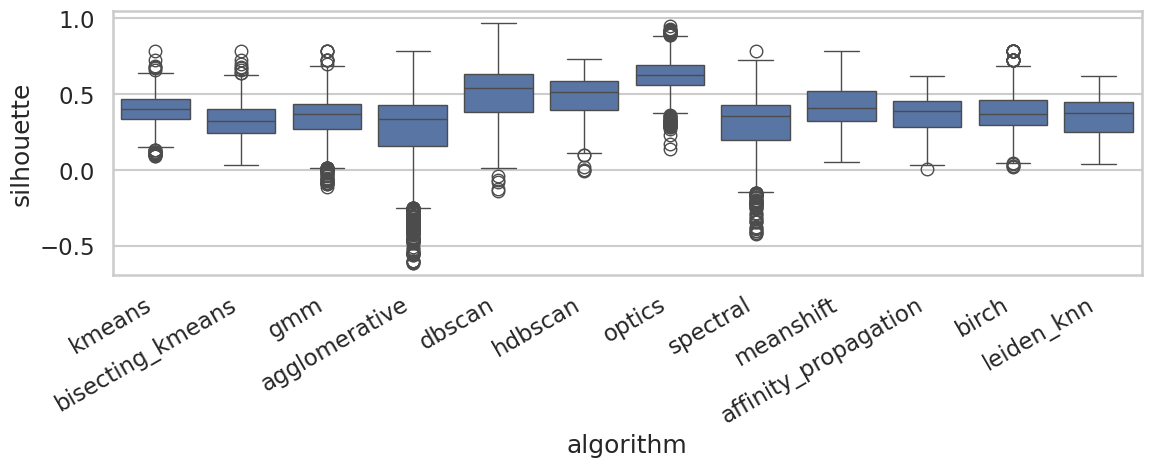

In [41]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=valid_results_df, x="algorithm", y="silhouette")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "silhouette_by_algorithm.png", dpi=300)
plt.show()

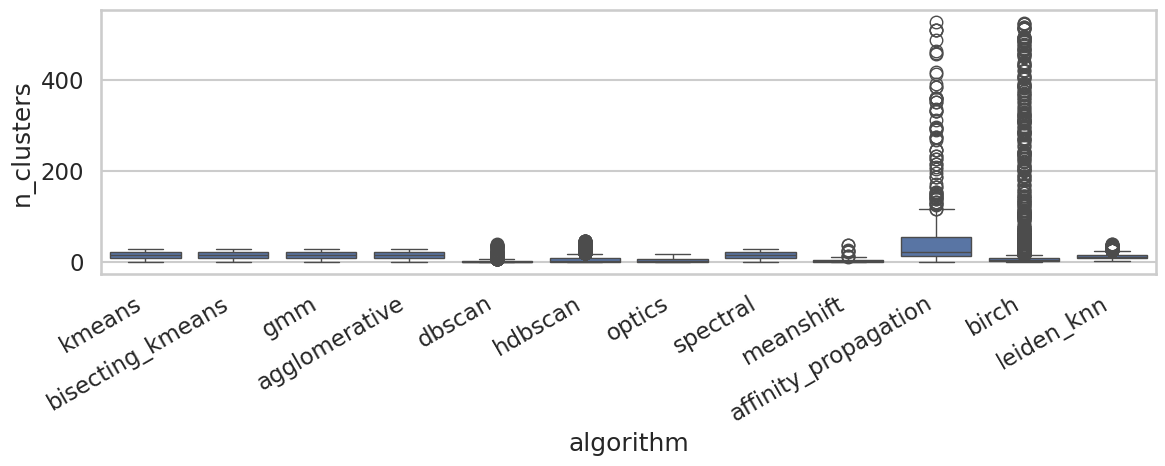

In [42]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=valid_results_df, x="algorithm", y="n_clusters")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "nclusters_by_algorithm.png", dpi=300)
plt.show()

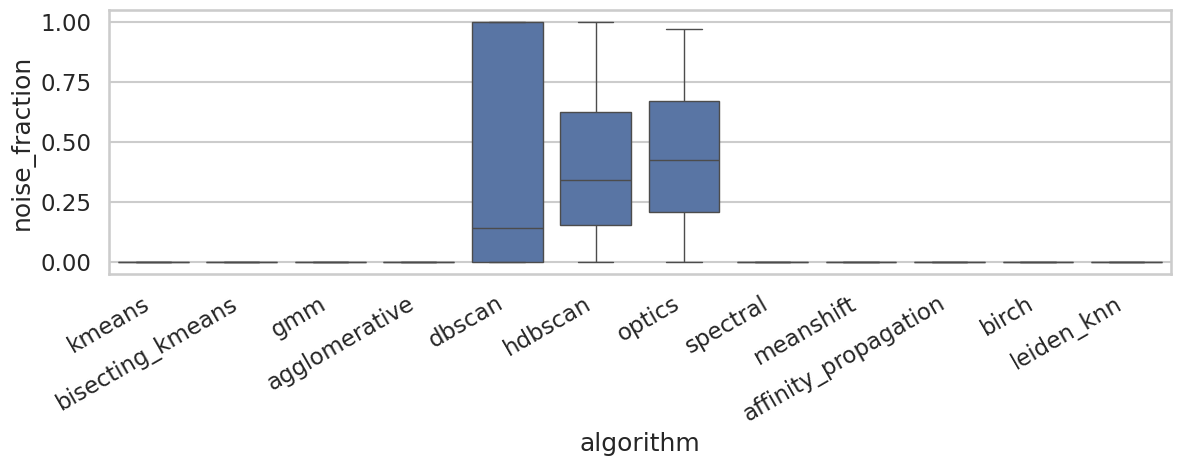

In [43]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=valid_results_df, x="algorithm", y="noise_fraction")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "noise_fraction_by_algorithm.png", dpi=300)
plt.show()

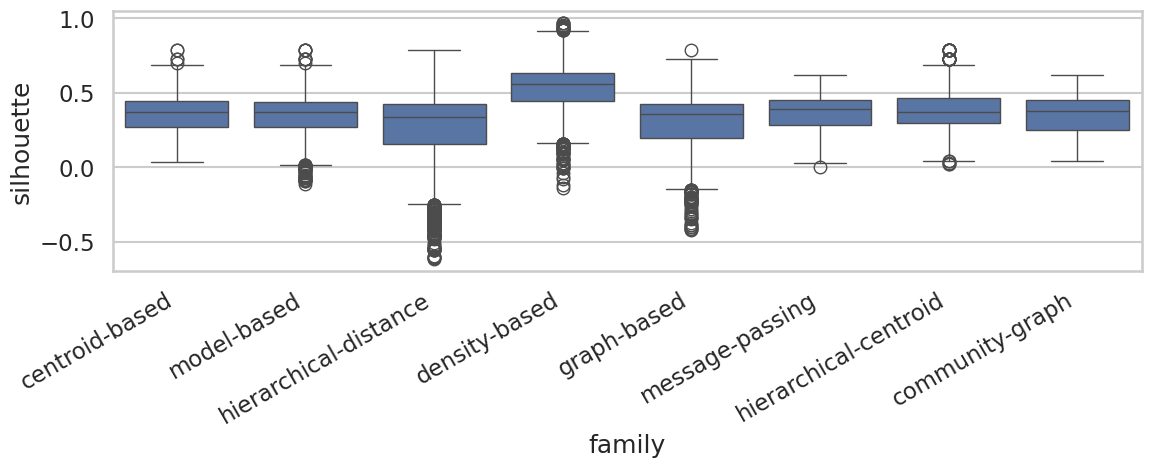

In [44]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=valid_results_df, x="family", y="silhouette")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "silhouette_by_family.png", dpi=300)
plt.show()

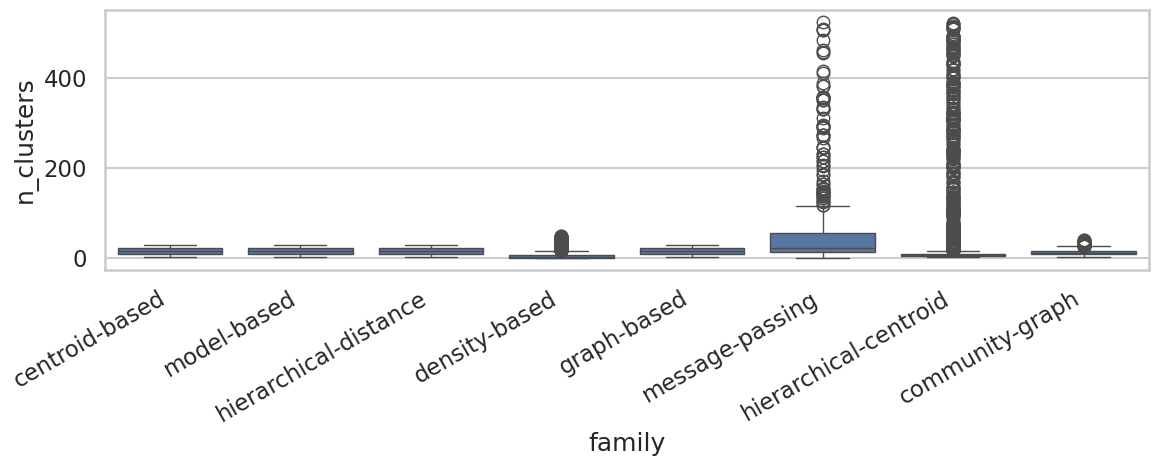

In [45]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=valid_results_df, x="family", y="n_clusters")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "nclusters_by_family.png", dpi=300)
plt.show()

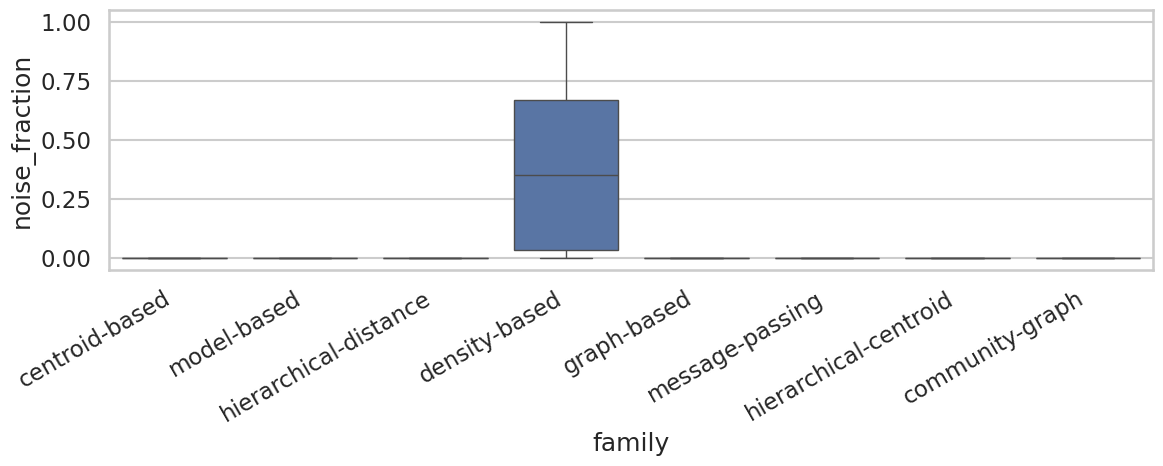

In [46]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=valid_results_df, x="family", y="noise_fraction")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "noise_fraction_by_family.png", dpi=300)
plt.show()

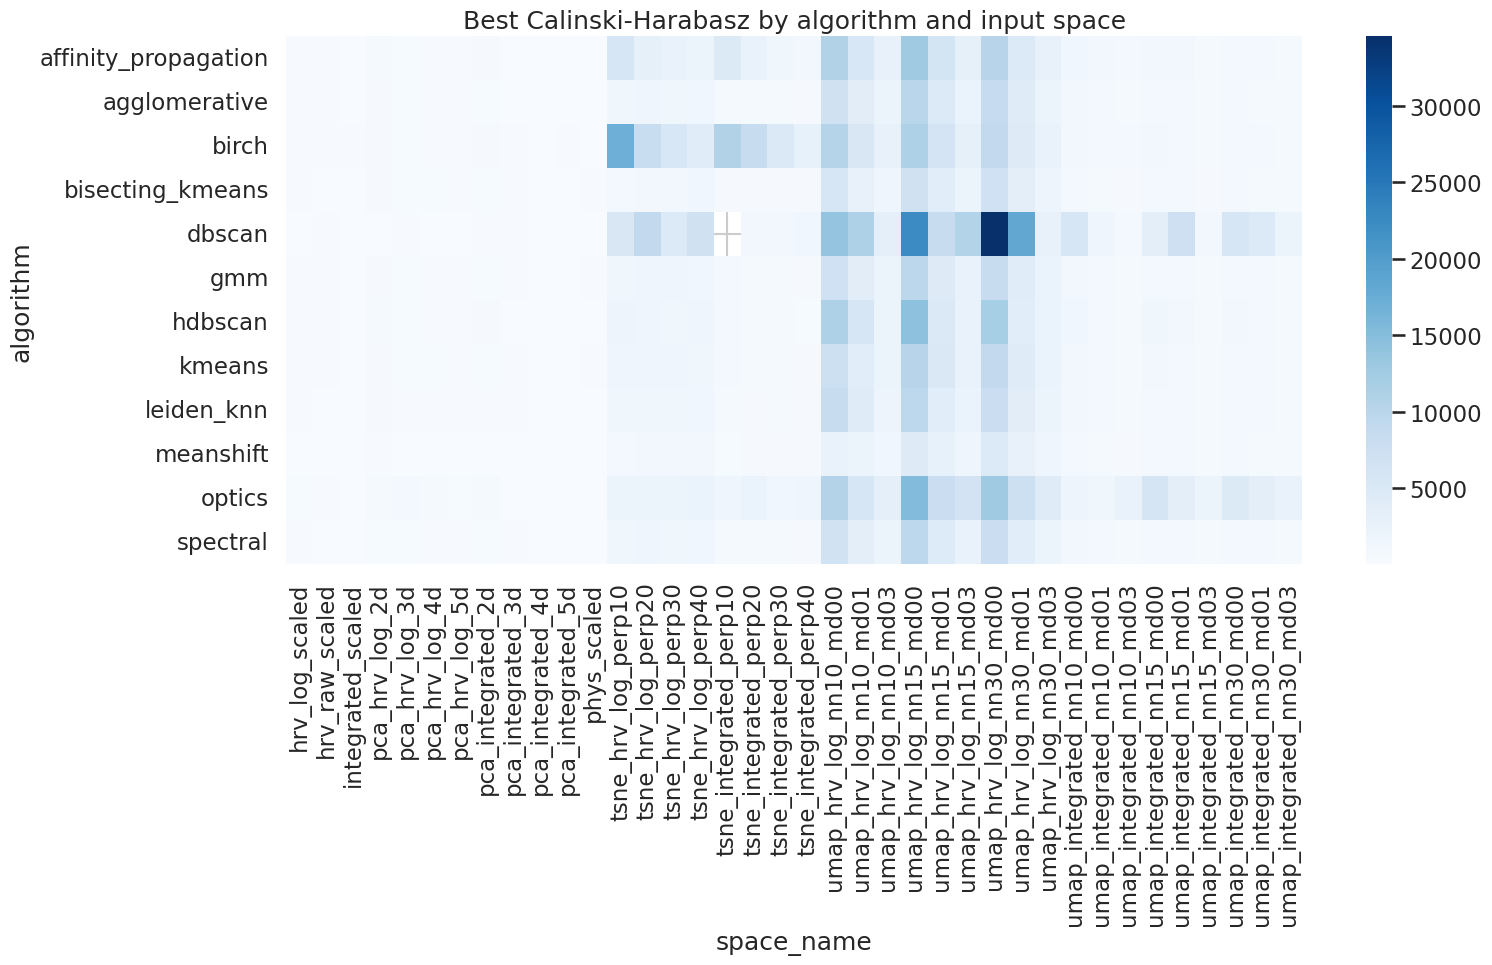

In [49]:
pivot_ch = valid_results_df.pivot_table(
    index="algorithm",
    columns="space_name",
    values="calinski_harabasz",
    aggfunc="max"
)

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_ch, cmap="Blues")
plt.title("Best Calinski-Harabasz by algorithm and input space")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_best_ch_algo_space.png", dpi=300)
plt.show()

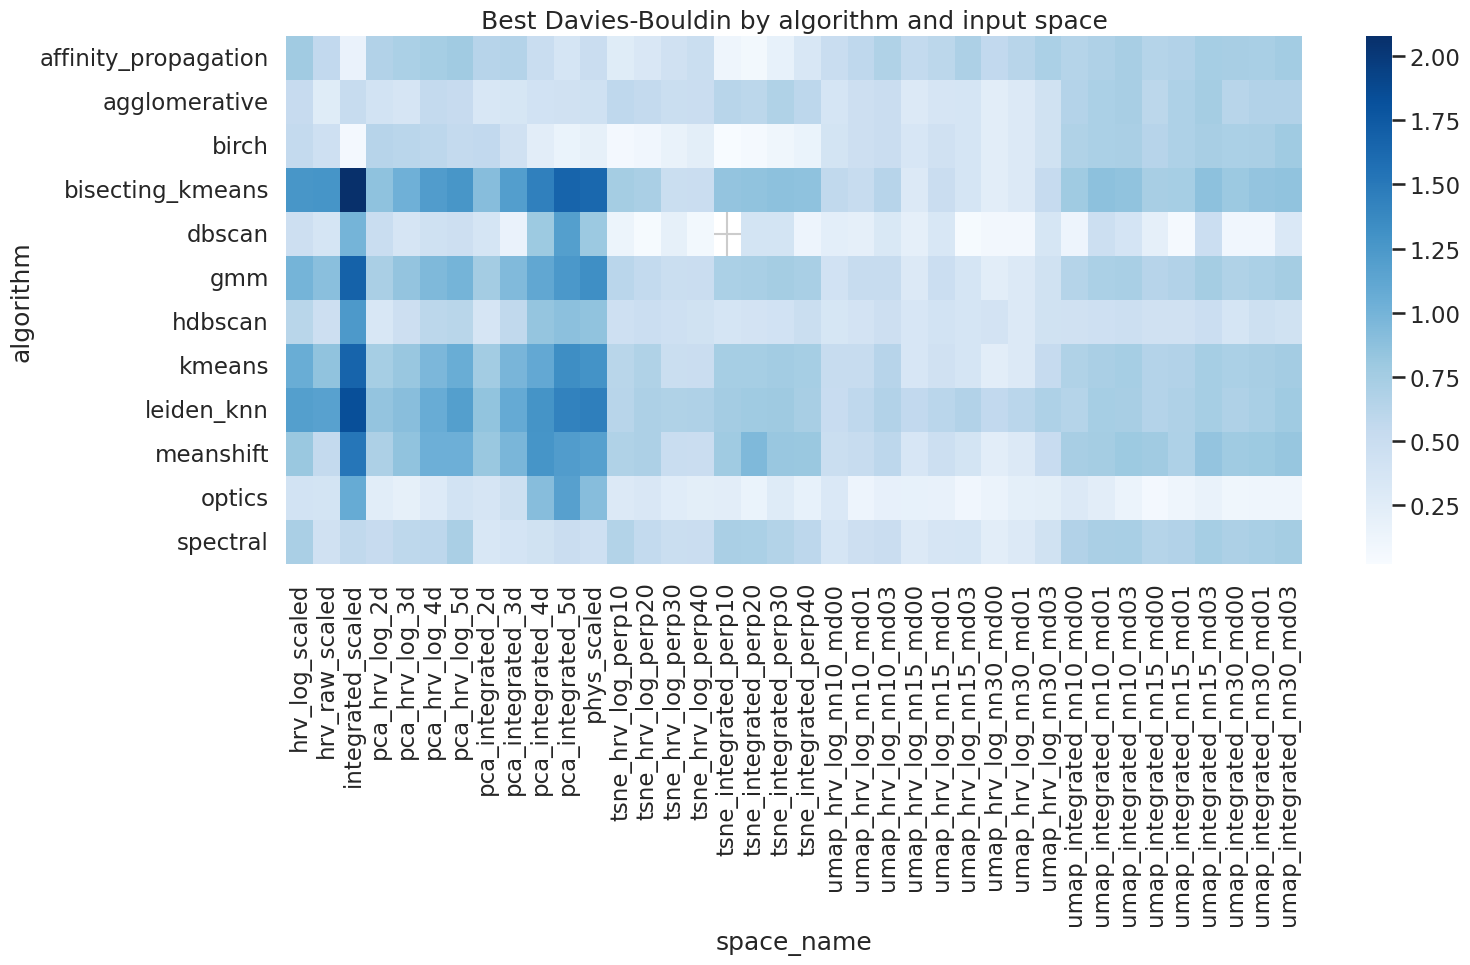

In [50]:
pivot_db = valid_results_df.pivot_table(
    index="algorithm",
    columns="space_name",
    values="davies_bouldin",
    aggfunc="min"
)

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_db, cmap="Blues")
plt.title("Best Davies-Bouldin by algorithm and input space")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_best_db_algo_space.png", dpi=300)
plt.show()

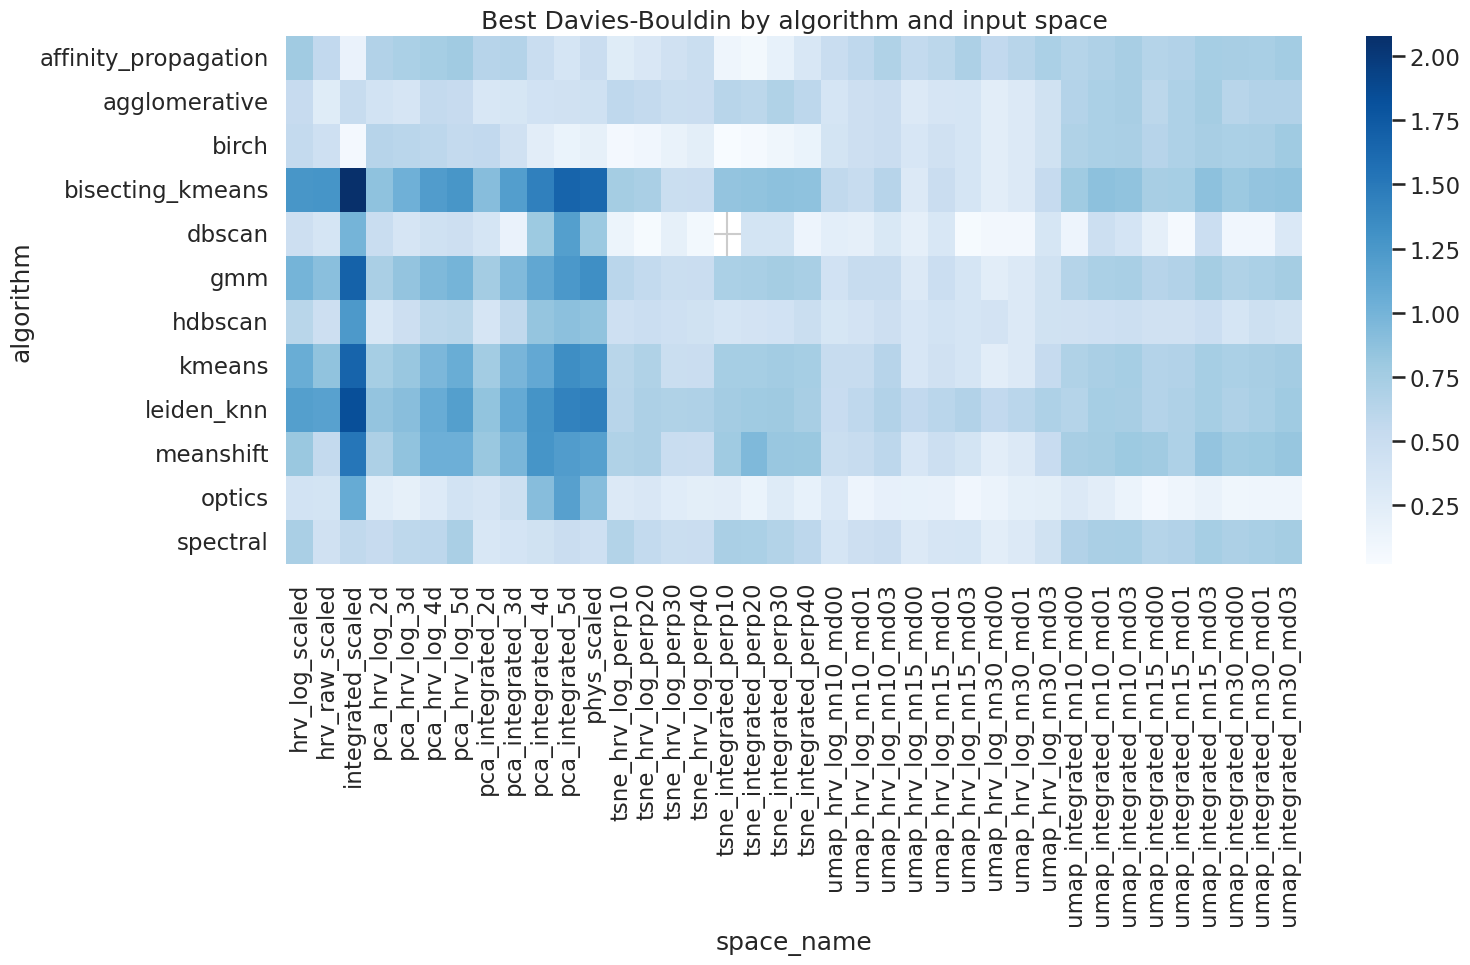

In [51]:
pivot_db = valid_results_df.pivot_table(
    index="algorithm",
    columns="space_name",
    values="davies_bouldin",
    aggfunc="min"
)

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_db, cmap="Blues")
plt.title("Best Davies-Bouldin by algorithm and input space")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_best_db_algo_space.png", dpi=300)
plt.show()

In [52]:
top_by_algorithm = (
    rank_balanced.groupby("algorithm")
    .head(10)
    .copy()
)

top_by_algorithm

,status,algorithm,family,space_name,params_json,n_clusters,n_noise,noise_fraction,n_clustered,min_cluster_size,...,imbalance_ratio,silhouette,calinski_harabasz,davies_bouldin,experiment_id,silhouette_rank,ch_rank,db_rank,noise_rank,consensus_rank_score
11506,ok,gmm,model-based,umap_hrv_log_nn30_md00,"{""covariance_type"": ""full"", ""n_components"": 2}",2,0,0.000000,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11506,145.0,2463.0,147.0,10165.0,12920.0
11991,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.000000,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11991,145.0,2463.0,147.0,10165.0,12920.0
11507,ok,gmm,model-based,umap_hrv_log_nn30_md00,"{""covariance_type"": ""diag"", ""n_components"": 2}",2,0,0.000000,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11507,145.0,2463.0,147.0,10165.0,12920.0
11961,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.000000,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11961,145.0,2463.0,147.0,10165.0,12920.0
11922,ok,meanshift,density-based,umap_hrv_log_nn30_md00,"{""n_samples"": null, ""quantile"": 0.3}",2,0,0.000000,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11922,145.0,2463.0,147.0,10165.0,12920.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11855,ok,optics,density-based,umap_hrv_log_nn30_md00,"{""min_cluster_size"": 0.05, ""min_samples"": 20, ...",8,221,0.416981,309,27.0,...,2.370370,0.753995,8215.086578,0.323285,11855,195.0,156.0,328.0,22052.5,22731.5
11823,ok,optics,density-based,umap_hrv_log_nn30_md00,"{""min_cluster_size"": 0.1, ""min_samples"": 5, ""x...",4,236,0.445283,294,55.0,...,2.018182,0.836249,7256.391293,0.264883,11823,63.0,276.0,195.0,22205.5,22739.5
9925,ok,optics,density-based,umap_hrv_log_nn15_md00,"{""min_cluster_size"": 0.03, ""min_samples"": 10, ...",13,237,0.447170,293,17.0,...,2.176471,0.763121,14598.964374,0.331117,9925,185.0,8.0,336.0,22225.0,22754.0
7996,ok,optics,density-based,umap_hrv_log_nn10_md00,"{""min_cluster_size"": 0.03, ""min_samples"": 5, ""...",16,238,0.449057,292,15.0,...,1.733333,0.780989,10550.881008,0.321492,7996,161.0,41.0,327.0,22237.0,22766.0


In [53]:
top_by_algorithm.to_csv(TABLE_DIR / "top10_by_algorithm_consensus.csv", index=False)

In [54]:
top_by_family = (
    rank_balanced.groupby("family")
    .head(10)
    .copy()
)

top_by_family

,status,algorithm,family,space_name,params_json,n_clusters,n_noise,noise_fraction,n_clustered,min_cluster_size,...,imbalance_ratio,silhouette,calinski_harabasz,davies_bouldin,experiment_id,silhouette_rank,ch_rank,db_rank,noise_rank,consensus_rank_score
11506,ok,gmm,model-based,umap_hrv_log_nn30_md00,"{""covariance_type"": ""full"", ""n_components"": 2}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11506,145.0,2463.0,147.0,10165.0,12920.0
11991,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11991,145.0,2463.0,147.0,10165.0,12920.0
11507,ok,gmm,model-based,umap_hrv_log_nn30_md00,"{""covariance_type"": ""diag"", ""n_components"": 2}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11507,145.0,2463.0,147.0,10165.0,12920.0
11961,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11961,145.0,2463.0,147.0,10165.0,12920.0
11922,ok,meanshift,density-based,umap_hrv_log_nn30_md00,"{""n_samples"": null, ""quantile"": 0.3}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11922,145.0,2463.0,147.0,10165.0,12920.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8251,ok,leiden_knn,community-graph,umap_hrv_log_nn10_md00,"{""n_neighbors"": 10, ""resolution"": 2.0}",26,0,0.0,530,11.0,...,3.000000,0.571805,5928.324340,0.555921,8251,2303.0,597.0,2628.0,10165.0,15693.0
10159,ok,leiden_knn,community-graph,umap_hrv_log_nn15_md00,"{""n_neighbors"": 10, ""resolution"": 2.0}",26,0,0.0,530,10.0,...,4.100000,0.553481,7349.163927,0.562031,10159,2781.0,261.0,2763.0,10165.0,15970.0
10172,ok,leiden_knn,community-graph,umap_hrv_log_nn15_md00,"{""n_neighbors"": 30, ""resolution"": 0.5}",6,0,0.0,530,67.0,...,1.656716,0.613814,4349.096064,0.581810,10172,1403.5,1145.0,3295.5,10165.0,16009.0
8249,ok,leiden_knn,community-graph,umap_hrv_log_nn10_md00,"{""n_neighbors"": 10, ""resolution"": 1.0}",22,0,0.0,530,12.0,...,3.666667,0.563665,5041.254840,0.559919,8249,2481.0,865.0,2717.0,10165.0,16228.0


In [55]:
top_by_family.to_csv(TABLE_DIR / "top10_by_family_consensus.csv", index=False)

In [56]:
top_by_space = (
    rank_balanced.groupby("space_name")
    .head(10)
    .copy()
)

top_by_space.head(30)

,status,algorithm,family,space_name,params_json,n_clusters,n_noise,noise_fraction,n_clustered,min_cluster_size,...,imbalance_ratio,silhouette,calinski_harabasz,davies_bouldin,experiment_id,silhouette_rank,ch_rank,db_rank,noise_rank,consensus_rank_score
11506,ok,gmm,model-based,umap_hrv_log_nn30_md00,"{""covariance_type"": ""full"", ""n_components"": 2}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11506,145.0,2463.0,147.0,10165.0,12920.0
11991,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11991,145.0,2463.0,147.0,10165.0,12920.0
11507,ok,gmm,model-based,umap_hrv_log_nn30_md00,"{""covariance_type"": ""diag"", ""n_components"": 2}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11507,145.0,2463.0,147.0,10165.0,12920.0
11961,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11961,145.0,2463.0,147.0,10165.0,12920.0
11922,ok,meanshift,density-based,umap_hrv_log_nn30_md00,"{""n_samples"": null, ""quantile"": 0.3}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11922,145.0,2463.0,147.0,10165.0,12920.0
11923,ok,meanshift,density-based,umap_hrv_log_nn30_md00,"{""n_samples"": 200, ""quantile"": 0.3}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11923,145.0,2463.0,147.0,10165.0,12920.0
12021,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,12021,145.0,2463.0,147.0,10165.0,12920.0
12041,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 50, ""n_clusters"": 2, ""thr...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,12041,145.0,2463.0,147.0,10165.0,12920.0
11981,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 50, ""n_clusters"": 2, ""thr...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11981,145.0,2463.0,147.0,10165.0,12920.0
11622,ok,agglomerative,hierarchical-distance,umap_hrv_log_nn30_md00,"{""linkage"": ""ward"", ""n_clusters"": 2}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11622,145.0,2463.0,147.0,10165.0,12920.0


In [57]:
top_by_space.to_csv(TABLE_DIR / "top10_by_space_consensus.csv", index=False)

In [58]:
top_global = rank_balanced.head(100).copy()
top_global

,status,algorithm,family,space_name,params_json,n_clusters,n_noise,noise_fraction,n_clustered,min_cluster_size,...,imbalance_ratio,silhouette,calinski_harabasz,davies_bouldin,experiment_id,silhouette_rank,ch_rank,db_rank,noise_rank,consensus_rank_score
11506,ok,gmm,model-based,umap_hrv_log_nn30_md00,"{""covariance_type"": ""full"", ""n_components"": 2}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11506,145.0,2463.0,147.0,10165.0,12920.0
11991,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11991,145.0,2463.0,147.0,10165.0,12920.0
11507,ok,gmm,model-based,umap_hrv_log_nn30_md00,"{""covariance_type"": ""diag"", ""n_components"": 2}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11507,145.0,2463.0,147.0,10165.0,12920.0
11961,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 100, ""n_clusters"": 2, ""th...",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11961,145.0,2463.0,147.0,10165.0,12920.0
11922,ok,meanshift,density-based,umap_hrv_log_nn30_md00,"{""n_samples"": null, ""quantile"": 0.3}",2,0,0.0,530,111.0,...,3.774775,0.784369,2738.734052,0.238637,11922,145.0,2463.0,147.0,10165.0,12920.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8101,ok,spectral,graph-based,umap_hrv_log_nn10_md00,"{""affinity"": ""rbf"", ""n_clusters"": 30}",30,0,0.0,530,5.0,...,7.200000,0.587364,6735.792113,0.514158,8101,1849.0,381.0,1900.0,10165.0,14295.0
11802,ok,hdbscan,density-based,umap_hrv_log_nn30_md00,"{""cluster_selection_method"": ""eom"", ""min_clust...",3,0,0.0,530,73.0,...,4.739726,0.624822,2904.092003,0.402067,11802,1244.0,2250.0,680.0,10165.0,14339.0
11942,ok,birch,hierarchical-centroid,umap_hrv_log_nn30_md00,"{""branching_factor"": 25, ""n_clusters"": 3, ""thr...",3,0,0.0,530,73.0,...,4.739726,0.624822,2904.092003,0.402067,11942,1244.0,2250.0,680.0,10165.0,14339.0
11626,ok,agglomerative,hierarchical-distance,umap_hrv_log_nn30_md00,"{""linkage"": ""ward"", ""n_clusters"": 3}",3,0,0.0,530,73.0,...,4.739726,0.624822,2904.092003,0.402067,11626,1244.0,2250.0,680.0,10165.0,14339.0


In [59]:
top_global.to_csv(TABLE_DIR / "top100_global_consensus.csv", index=False)

In [60]:
error_results_df = results_df[results_df["status"] == "error"].copy()
error_results_df.shape

(0, 18)

In [61]:
if not error_results_df.empty:
    error_results_df["algorithm"].value_counts()

In [62]:
if not error_results_df.empty:
    error_results_df.to_csv(TABLE_DIR / "clustering_errors.csv", index=False)

In [63]:
metadata = {
    "n_subjects": int(df.shape[0]),
    "n_input_spaces": int(len(input_spaces)),
    "input_spaces": list(input_spaces.keys()),
    "n_total_experiments": int(len(experiments)),
    "n_valid_experiments": int(len(valid_results_df)),
    "n_error_experiments": int(len(error_results_df)),
    "algorithms_tested": sorted(list(set(exp["algorithm"] for exp in experiments))),
    "families_tested": sorted(list(set(exp["family"] for exp in experiments))),
    "has_umap": HAS_UMAP,
    "has_leiden": HAS_LEIDEN,
}

with open(META_DIR / "clustering_exploration_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

metadata

{'n_subjects': 530,
 'n_input_spaces': 38,
 'input_spaces': ['hrv_raw_scaled',
  'hrv_log_scaled',
  'phys_scaled',
  'integrated_scaled',
  'pca_hrv_log_2d',
  'pca_hrv_log_3d',
  'pca_hrv_log_4d',
  'pca_hrv_log_5d',
  'pca_integrated_2d',
  'pca_integrated_3d',
  'pca_integrated_4d',
  'pca_integrated_5d',
  'umap_hrv_log_nn10_md00',
  'umap_hrv_log_nn10_md01',
  'umap_hrv_log_nn10_md03',
  'umap_hrv_log_nn15_md00',
  'umap_hrv_log_nn15_md01',
  'umap_hrv_log_nn15_md03',
  'umap_hrv_log_nn30_md00',
  'umap_hrv_log_nn30_md01',
  'umap_hrv_log_nn30_md03',
  'umap_integrated_nn10_md00',
  'umap_integrated_nn10_md01',
  'umap_integrated_nn10_md03',
  'umap_integrated_nn15_md00',
  'umap_integrated_nn15_md01',
  'umap_integrated_nn15_md03',
  'umap_integrated_nn30_md00',
  'umap_integrated_nn30_md01',
  'umap_integrated_nn30_md03',
  'tsne_hrv_log_perp10',
  'tsne_hrv_log_perp20',
  'tsne_hrv_log_perp30',
  'tsne_hrv_log_perp40',
  'tsne_integrated_perp10',
  'tsne_integrated_perp20',
  

In [64]:
summary_exec = {
    "best_silhouette_experiment_id": int(rank_silhouette.iloc[0]["experiment_id"]) if not rank_silhouette.empty else None,
    "best_silhouette_algorithm": rank_silhouette.iloc[0]["algorithm"] if not rank_silhouette.empty else None,
    "best_silhouette_family": rank_silhouette.iloc[0]["family"] if not rank_silhouette.empty else None,
    "best_silhouette_space": rank_silhouette.iloc[0]["space_name"] if not rank_silhouette.empty else None,
    "best_silhouette_value": float(rank_silhouette.iloc[0]["silhouette"]) if not rank_silhouette.empty else None,

    "best_consensus_experiment_id": int(rank_balanced.iloc[0]["experiment_id"]) if not rank_balanced.empty else None,
    "best_consensus_algorithm": rank_balanced.iloc[0]["algorithm"] if not rank_balanced.empty else None,
    "best_consensus_family": rank_balanced.iloc[0]["family"] if not rank_balanced.empty else None,
    "best_consensus_space": rank_balanced.iloc[0]["space_name"] if not rank_balanced.empty else None,
    "best_consensus_score": float(rank_balanced.iloc[0]["consensus_rank_score"]) if not rank_balanced.empty else None,
}

pd.Series(summary_exec, name="value")

best_silhouette_experiment_id                     11103
best_silhouette_algorithm                        dbscan
best_silhouette_family                    density-based
best_silhouette_space            umap_hrv_log_nn15_md03
best_silhouette_value                           0.96993
best_consensus_experiment_id                      11506
best_consensus_algorithm                            gmm
best_consensus_family                       model-based
best_consensus_space             umap_hrv_log_nn30_md00
best_consensus_score                            12920.0
Name: value, dtype: object

In [65]:
pd.Series(summary_exec, name="value").to_csv(TABLE_DIR / "clustering_executive_summary.csv")

In [66]:
rank_silhouette.to_csv(TABLE_DIR / "ranking_silhouette.csv", index=False)
rank_ch.to_csv(TABLE_DIR / "ranking_calinski_harabasz.csv", index=False)
rank_db.to_csv(TABLE_DIR / "ranking_davies_bouldin.csv", index=False)
rank_balanced.to_csv(TABLE_DIR / "ranking_consensus.csv", index=False)

In [67]:
final_check = {
    "results_table_exists": (TABLE_DIR / "clustering_exploration_results.csv").exists(),
    "label_index_exists": (TABLE_DIR / "clustering_label_index.csv").exists(),
    "metadata_exists": (META_DIR / "clustering_exploration_metadata.json").exists(),
    "n_label_files": len(list(LABEL_DIR.glob("labels_exp_*.csv"))),
}

pd.Series(final_check, name="value")

results_table_exists     True
label_index_exists       True
metadata_exists          True
n_label_files           24168
Name: value, dtype: object